In [1]:
# ============================================================
# PHASE — CORRIDOR RISK RANKING ENGINE
# ============================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

with open('phase3_checkpoint.pkl', 'rb') as f:
    p3 = pickle.load(f)

corridor_stats  = p3['corridor_stats']
hub_df          = p3['hub_df']
trip_agg        = p3['trip_agg']
G               = p3['G']
THRESHOLD_SEVERE= p3['THRESHOLD_SEVERE']

print(f"✅ Loaded | corridors: {len(corridor_stats)} | hubs: {len(hub_df)}")

print(f"Before filter: {len(corridor_stats)} corridors")

corridor_stats_risk = corridor_stats[
    corridor_stats['trip_count'] >= 3
].copy()

print(f"After filter (≥3 trips): {len(corridor_stats_risk)} corridors")
print(f"Removed: {len(corridor_stats) - len(corridor_stats_risk)} low-volume corridors")

✅ Loaded | corridors: 2804 | hubs: 1657
Before filter: 2804 corridors
After filter (≥3 trips): 1946 corridors
Removed: 858 low-volume corridors


In [4]:
# ── Risk Score Framework ──────────────────────────────────────
# Formula (0-100 scale):
# risk = 25×norm(delay_ratio) + 20×norm(breach_rate) + 20×norm(src_betweenness)
#      + 15×norm(dst_betweenness) + 10×norm(volume) + 10×(FTL_penalty)
# Weights chosen to reflect: delay severity > structural risk > volume impact
# Route type: FTL corridors with high delay get 10-point penalty (harder to reroute)

def normalize_0_100(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn + 1e-8) * 100
hub_index = hub_df.set_index('facility')

corridor_stats_risk['src_betweenness'] = (
    corridor_stats_risk['source_center'].astype(str)
    .map(hub_index['betweenness']).fillna(0)
)
corridor_stats_risk['dst_betweenness'] = (
    corridor_stats_risk['destination_center'].astype(str)
    .map(hub_index['betweenness']).fillna(0)
)
corridor_stats_risk['src_bottleneck'] = (
    corridor_stats_risk['source_center'].astype(str)
    .map(hub_index['bottleneck_score']).fillna(0)
)
corridor_stats_risk['dst_bottleneck'] = (
    corridor_stats_risk['destination_center'].astype(str)
    .map(hub_index['bottleneck_score']).fillna(0)
)
corridor_stats_risk['src_volume'] = (
    corridor_stats_risk['source_center'].astype(str)
    .map(hub_index['trip_volume']).fillna(0)
)

# Normalized components
n_delay    = normalize_0_100(corridor_stats_risk['median_delay_ratio'])
n_breach   = normalize_0_100(corridor_stats_risk['sla_severe_rate'])
n_src_btw  = normalize_0_100(corridor_stats_risk['src_betweenness'])
n_dst_btw  = normalize_0_100(corridor_stats_risk['dst_betweenness'])
n_volume   = normalize_0_100(corridor_stats_risk['trip_count'])
ftl_penalty= (corridor_stats_risk['route_type'] == 'FTL').astype(int) * 10



corridor_stats_risk['risk_score'] = (
    0.25 * n_delay   +
    0.20 * n_breach  +
    0.20 * n_src_btw +
    0.15 * n_dst_btw +
    0.10 * n_volume  +
    ftl_penalty * 0.10
).clip(0, 100)

# Categorize
# Use data-driven thresholds instead of fixed 25/50/75/100
p60 = corridor_stats_risk['risk_score'].quantile(0.60)
p80 = corridor_stats_risk['risk_score'].quantile(0.80)
p95 = corridor_stats_risk['risk_score'].quantile(0.95)

corridor_stats_risk['risk_category'] = pd.cut(
    corridor_stats_risk['risk_score'],
    bins=[0, p60, p80, p95, 100],
    labels=['Low','Medium','High','Critical'],
    include_lowest=True
)

print(f"Thresholds: Low<{p60:.1f} | Medium<{p80:.1f} | "
      f"High<{p95:.1f} | Critical≥{p95:.1f}")
print("\n=== RISK CATEGORY DISTRIBUTION ===")
print(corridor_stats_risk['risk_category'].value_counts().sort_index(ascending=False))

print(f"\n=== TOP 20 HIGHEST RISK CORRIDORS ===")
top20 = corridor_stats_risk.nlargest(20, 'risk_score')[
    ['source_center','destination_center','route_type',
     'median_delay_ratio','sla_severe_rate','trip_count',
     'risk_score','risk_category','is_chronic']
].reset_index(drop=True)
print(top20.round(3).to_string())

Thresholds: Low<8.6 | Medium<12.6 | High<22.3 | Critical≥22.3

=== RISK CATEGORY DISTRIBUTION ===
risk_category
Critical      98
High         291
Medium       389
Low         1168
Name: count, dtype: int64

=== TOP 20 HIGHEST RISK CORRIDORS ===
   source_center destination_center route_type  median_delay_ratio  sla_severe_rate  trip_count  risk_score risk_category  is_chronic
0   IND743270AAA       IND712311AAA        FTL              15.351            1.000           5      51.109      Critical           1
1   IND741201AAC       IND712311AAA        FTL              15.272            1.000           4      50.908      Critical           1
2   IND844505AAB       IND842001AAA        FTL              11.357            0.938          14      40.220      Critical           1
3   IND751002AAB       IND754103AAA        FTL              10.250            1.000           7      39.583      Critical           1
4   IND722151AAA       IND723130AAA        FTL              14.208            0.700  

In [5]:
# ── Add Hub Centrality Features to Filtered Corridor Data ─────
hub_lookup = hub_df.set_index('facility')

corridor_stats_risk['src_betweenness'] = (
    corridor_stats_risk['source_center'].astype(str)
    .map(hub_lookup['betweenness'])
    .fillna(0)
)

corridor_stats_risk['dst_betweenness'] = (
    corridor_stats_risk['destination_center'].astype(str)
    .map(hub_lookup['betweenness'])
    .fillna(0)
)

src_betweenness_p80 = corridor_stats_risk['src_betweenness'].quantile(0.80)
trip_count_p80 = corridor_stats_risk['trip_count'].quantile(0.80)


# ── Root Cause Classification ─────────────────────────────────
def classify_root_cause(row):
    if row['median_delay_ratio'] > 4.0 and row['sla_severe_rate'] > 0.5:
        return 'Chronic delay + high breach — facility capacity issue'

    elif row['src_betweenness'] > src_betweenness_p80:
        return 'High-centrality source hub — network congestion propagation'

    elif row['route_type'] == 'FTL' and row['median_delay_ratio'] > 3.0:
        return 'FTL long-haul delay — route optimization needed'

    elif row['trip_count'] > trip_count_p80:
        return 'High-volume corridor — capacity saturation'

    else:
        return 'Moderate multi-factor risk — monitoring required'


corridor_stats_risk['root_cause'] = corridor_stats_risk.apply(
    classify_root_cause,
    axis=1
)

print("\n=== ROOT CAUSE DISTRIBUTION ===")
print(corridor_stats_risk['root_cause'].value_counts())


# ── Intervention Recommendations ─────────────────────────────
def recommend_intervention(row):
    if row['risk_category'] == 'Critical':
        if row['route_type'] == 'FTL':
            return 'Immediate: Add parallel FTL route or upgrade source facility'
        else:
            return 'Immediate: Convert to FTL on this corridor + capacity audit'

    elif row['risk_category'] == 'High':
        return 'Short-term: SLA alert + weekly delay review + route-type evaluation'

    elif row['risk_category'] == 'Medium':
        return 'Medium-term: Monthly monitoring + consider schedule optimization'

    else:
        return 'Low priority: Standard operations monitoring'


corridor_stats_risk['intervention'] = corridor_stats_risk.apply(
    recommend_intervention,
    axis=1
)

print("\n=== TOP 10 CRITICAL CORRIDORS WITH RECOMMENDATIONS ===")

critical = (
    corridor_stats_risk[corridor_stats_risk['risk_category'] == 'Critical']
    .nlargest(10, 'risk_score')
)

for _, row in critical.iterrows():
    print(f"\n  {row['source_center']} → {row['destination_center']} "
          f"({row['route_type']})")
    print(f"  Risk: {row['risk_score']:.1f}/100 | "
          f"Delay: {row['median_delay_ratio']:.2f}x | "
          f"Breach: {row['sla_severe_rate']:.1%} | "
          f"Trips: {int(row['trip_count'])}")
    print(f"  Root cause: {row['root_cause']}")
    print(f"  Action: {row['intervention']}")


=== ROOT CAUSE DISTRIBUTION ===
root_cause
Moderate multi-factor risk — monitoring required               1257
High-centrality source hub — network congestion propagation     387
High-volume corridor — capacity saturation                      233
Chronic delay + high breach — facility capacity issue            36
FTL long-haul delay — route optimization needed                  33
Name: count, dtype: int64

=== TOP 10 CRITICAL CORRIDORS WITH RECOMMENDATIONS ===

  IND743270AAA → IND712311AAA (FTL)
  Risk: 51.1/100 | Delay: 15.35x | Breach: 100.0% | Trips: 5
  Root cause: Chronic delay + high breach — facility capacity issue
  Action: Immediate: Add parallel FTL route or upgrade source facility

  IND741201AAC → IND712311AAA (FTL)
  Risk: 50.9/100 | Delay: 15.27x | Breach: 100.0% | Trips: 4
  Root cause: Chronic delay + high breach — facility capacity issue
  Action: Immediate: Add parallel FTL route or upgrade source facility

  IND844505AAB → IND842001AAA (FTL)
  Risk: 40.2/100 | Dela


Plot saved: corridor_risk_ranking.png


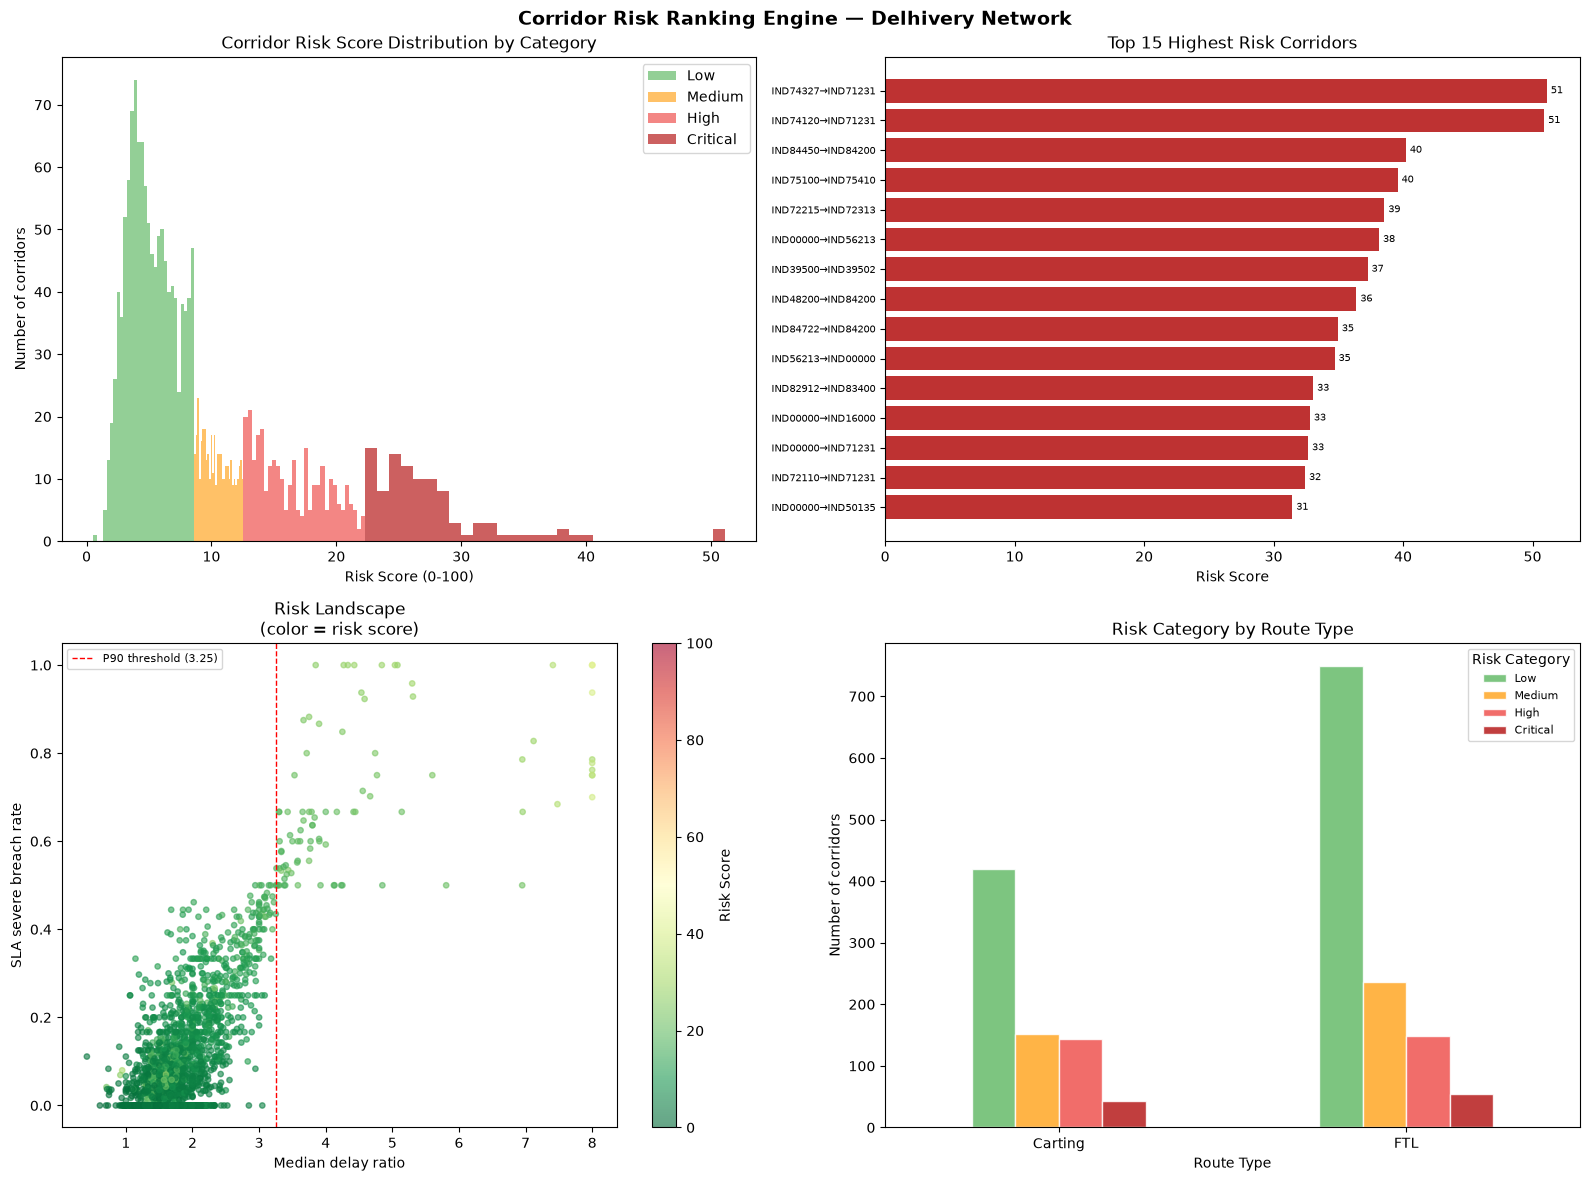

In [7]:

# ── Visualizations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Risk score distribution by category
cat_colors = {'Low':'#66BB6A','Medium':'#FFA726',
               'High':'#EF5350','Critical':'#B71C1C'}
for cat, color in cat_colors.items():
    subset = corridor_stats_risk[corridor_stats_risk['risk_category']==cat]['risk_score']
    axes[0,0].hist(subset, bins=30, alpha=0.7, color=color, label=cat, edgecolor='none')
axes[0,0].set_xlabel('Risk Score (0-100)')
axes[0,0].set_ylabel('Number of corridors')
axes[0,0].set_title('Corridor Risk Score Distribution by Category')
axes[0,0].legend()

# 2. Top 20 corridors bar chart
top20_plot = top20.head(15).copy()
top20_plot['label'] = (top20_plot['source_center'].str[:8] + '→' +
                       top20_plot['destination_center'].str[:8])
bar_colors = [cat_colors.get(str(c), 'gray') for c in top20_plot['risk_category']]
axes[0,1].barh(range(len(top20_plot)), top20_plot['risk_score'].values,
               color=bar_colors, alpha=0.9)
axes[0,1].set_yticks(range(len(top20_plot)))
axes[0,1].set_yticklabels(top20_plot['label'].values, fontsize=7)
axes[0,1].set_xlabel('Risk Score')
axes[0,1].set_title('Top 15 Highest Risk Corridors')
axes[0,1].invert_yaxis()
for i, (_, row) in enumerate(top20_plot.iterrows()):
    axes[0,1].text(row['risk_score']+0.3, i,
                   f"{row['risk_score']:.0f}", va='center', fontsize=7)

# 3. Risk score components scatter
sc = axes[1,0].scatter(
    corridor_stats_risk['median_delay_ratio'].clip(0,8),
    corridor_stats_risk['sla_severe_rate'],
    c=corridor_stats_risk['risk_score'],
    cmap='RdYlGn_r', alpha=0.6, s=15,
    vmin=0, vmax=100
)
plt.colorbar(sc, ax=axes[1,0], label='Risk Score')
axes[1,0].set_xlabel('Median delay ratio')
axes[1,0].set_ylabel('SLA severe breach rate')
axes[1,0].set_title('Risk Landscape\n(color = risk score)')
axes[1,0].axvline(THRESHOLD_SEVERE, color='red',
                  linestyle='--', lw=1, label=f'P90 threshold ({THRESHOLD_SEVERE:.2f})')
axes[1,0].legend(fontsize=8)

# 4. Risk by route type
risk_by_rt = corridor_stats_risk.groupby(
    ['route_type','risk_category'], observed=True
)['risk_score'].count().unstack(fill_value=0)
risk_by_rt.plot(kind='bar', ax=axes[1,1], color=list(cat_colors.values()),
                alpha=0.85, edgecolor='white')
axes[1,1].set_xlabel('Route Type')
axes[1,1].set_ylabel('Number of corridors')
axes[1,1].set_title('Risk Category by Route Type')
axes[1,1].legend(title='Risk Category', fontsize=8)
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('Corridor Risk Ranking Engine — Delhivery Network',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('corridor_risk_ranking.png', dpi=150, bbox_inches='tight')
print("\nPlot saved: corridor_risk_ranking.png")
plt.show()

In [8]:
# Save
with open('corridor_risk_results.pkl', 'wb') as f:
    pickle.dump({
        'corridor_stats_risk': corridor_stats_risk,
        'top20': top20,
    }, f, protocol=4)
print("✅ Saved corridor_risk_results.pkl")

✅ Saved corridor_risk_results.pkl
